In [1]:
import matplotlib.pyplot as plt

In [2]:
from ults.config import load_config

In [3]:
config = load_config('config/train.yml')

In [4]:
from training.dice_score.dataset import S7DatasetDiceClassification, S7DatasetDiceClassificationConfig
from training.dice_score.data import get_dice_crops

In [5]:
# Load all dice crops
dice_crops = get_dice_crops(dataset_path=config.dataset_path, num_workers=4)

dataset = S7DatasetDiceClassification(
    config=S7DatasetDiceClassificationConfig(
        image_resolution=(32, 32)
    ),
    dice_crops=dice_crops
)

In [6]:
# Create iterator for the dataset
data_iter = iter(dataset)

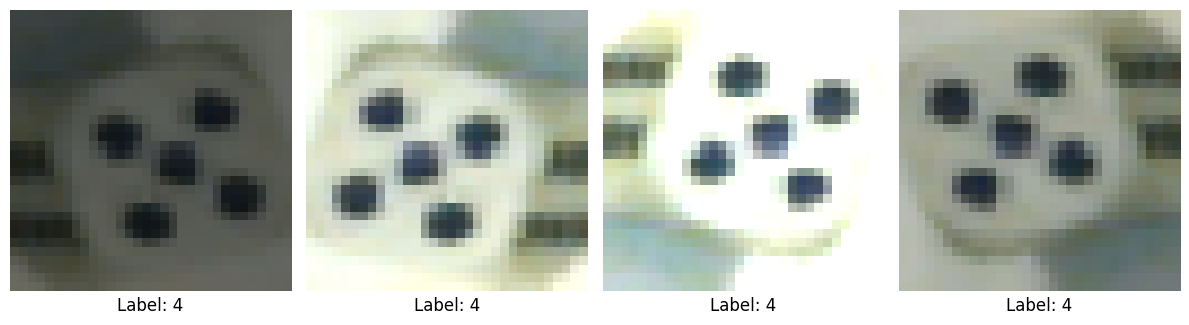

In [7]:
# Get 4 images from the iterator
images_and_labels = []
for _ in range(4):
    img, lbl = next(data_iter)
    images_and_labels.append((img, lbl))

# Create 1x4 grid
fig, axes = plt.subplots(1, 4, figsize=(12, 12))
axes = axes.flatten()

for i, (image, label) in enumerate(images_and_labels):
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f'Label: {label}', y=-0.1)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
images_and_labels[0][0].shape

(32, 32, 3)

In [9]:
from training.dice_detection.dataset import S7DatasetDiceDetection, S7DatasetDiceDetectionConfig

In [10]:
detection_dataset = S7DatasetDiceDetection(config=S7DatasetDiceDetectionConfig(
    dataset_path=config.dataset_path
))

In [11]:
# Create iterator for the detection dataset
detection_iter = iter(detection_dataset)

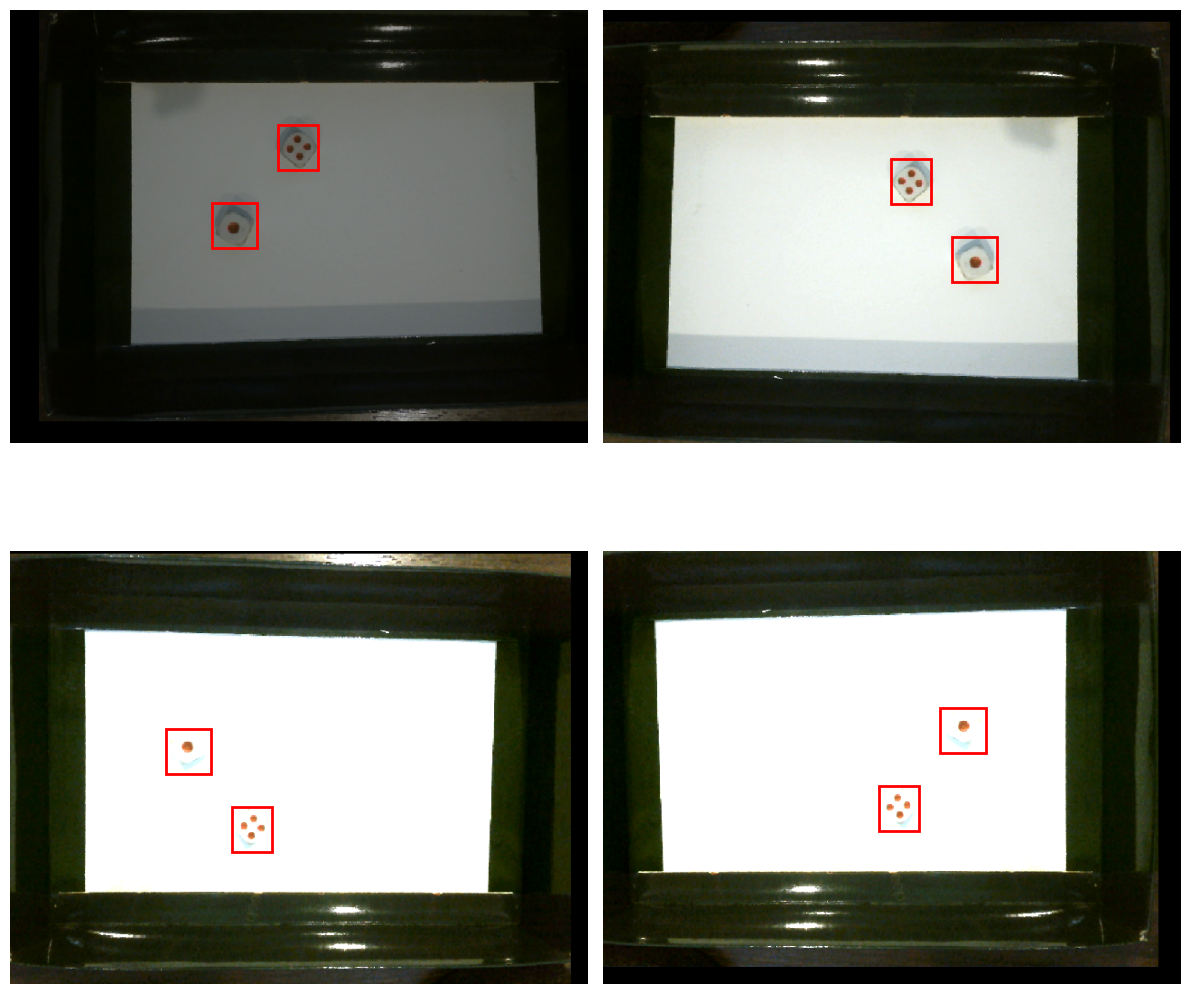

In [12]:
from matplotlib.patches import Rectangle

# Get 4 images from the iterator
detection_samples = []
for _ in range(4):
    img, bboxes = next(detection_iter)
    detection_samples.append((img, bboxes))

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (image, bboxes) in enumerate(detection_samples):
    axes[i].imshow(image)
    for bbox in bboxes:
        x, y, w, h = bbox
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        axes[i].add_patch(rect)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [13]:
print(f"Image shape: {detection_samples[0][0].shape}")

Image shape: (480, 640, 3)
